In [1]:
import os
import warnings

from matplotlib.pyplot import figure
from pyparsing import line_start
from scipy.stats import alpha

warnings.filterwarnings('ignore')
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,precision_recall_curve, average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

try:
    import xgboost as xgb
except:
    xgb = None
import joblib
print('Setup  complete')

Setup  complete


In [2]:
#Loading data

DATA_PATH = 'Fraud.csv'
assert os.path.exists(DATA_PATH), 'Dataset not found'
df = pd.read_csv(DATA_PATH)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
print('Shape: ', df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df['isFraud'].value_counts())
print('Fraud Ratio: ', df['isFraud'].mean())

Shape:  (6362620, 11)
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64
isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud Ratio:  0.001290820448180152


Text(0.5, 1.0, 'Fraud Rate by Transaction Amount Bucket')

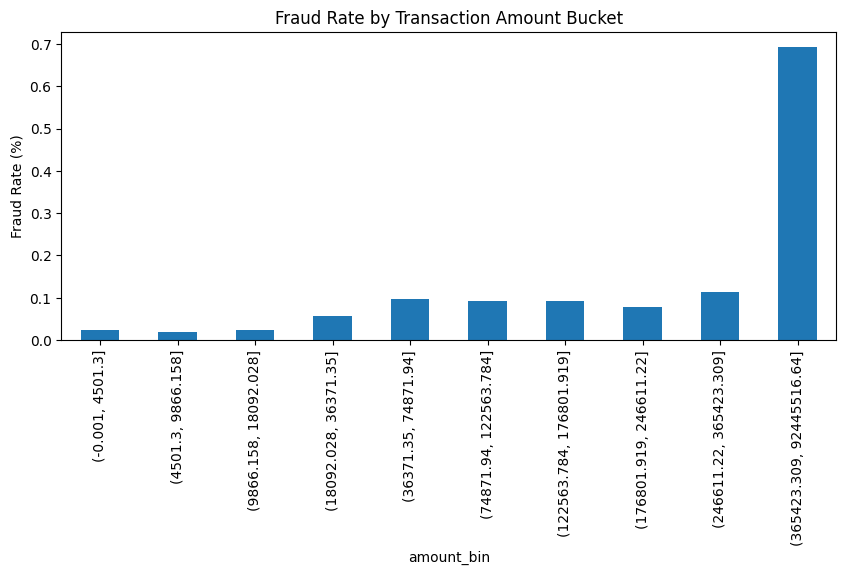

In [4]:
#Fraud Rate by Amount Bucket

df['amount_bin'] = pd.qcut(df['amount'], q=10, duplicates='drop')

fraud_rate = df.groupby('amount_bin')['isFraud'].mean()
fraud_rate = fraud_rate * 100

plt.figure(figsize=(10,4))
fraud_rate.plot(kind='bar')
plt.ylabel("Fraud Rate (%)")

plt.title("Fraud Rate by Transaction Amount Bucket")

This analysis demonstrates that transaction amount is not just a magnitude feature but a strong risk indicator, with fraud likelihood increasing significantly in higher value transactions.

In [5]:
#Checking missing values
df.isnull().sum()

#Checking merchant transactions (destination starting with 'M')
merchant_transactions = df[df['nameDest'].str.startswith('M')]
merchant_transactions[['oldbalanceDest','newbalanceDest']].describe()

,oldbalanceDest,newbalanceDest
count,2151495.0,2151495.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


No imputation needed, as zero represent valid merchant behaviour, not missing data.

Text(0.5, 1.0, 'Transaction Amount Distribution')

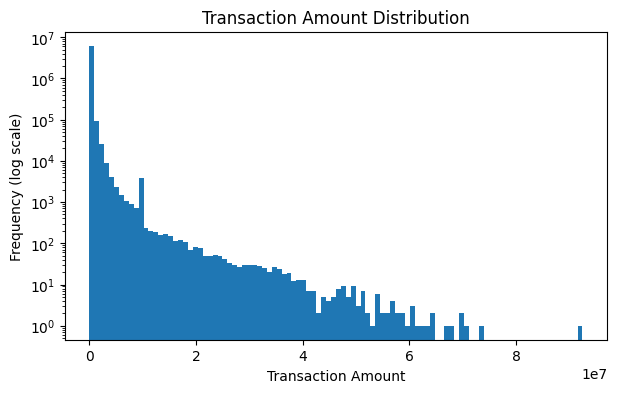

In [6]:
#Outlier Handling
df['amount'].describe()

#Visualise
plt.figure(figsize=(7,4))
plt.hist(df['amount'], bins=100)
plt.yscale('log')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency (log scale)')
plt.title('Transaction Amount Distribution')

In [7]:
#Log transform to reduce skewness
df['log_amount'] = np.log1p(df['amount'])

#Flag transactions above 99th percentile
p99 = df['amount'].quantile(0.99)
df['is_high_amount'] = (df['amount'] > p99).astype(int)
df['is_high_amount'].value_counts()

is_high_amount
0    6298993
1      63627
Name: count, dtype: int64

In [8]:
#Overview
total_transactions = len(df)
fraud_transactions = df['isFraud'].sum()
fraud_rate = fraud_transactions / total_transactions
fraud_percent = (df['isFraud'].sum() / total_transactions) * 100
flagged_percent = (df['isFlaggedFraud'].sum() / total_transactions) * 100

print(f"Total transactions: {total_transactions}")
print(f"Fraud transactions: {fraud_transactions}")
print(f"Overall fraud rate: {fraud_rate:.4%}")
print(f"Fraudulent transaction (isFraud=1): {fraud_percent:.4f}%")
print(f"Flagged transactions (isFlaggedFraud=1): {flagged_percent:.4f}%")

Total transactions: 6362620
Fraud transactions: 8213
Overall fraud rate: 0.1291%
Fraudulent transaction (isFraud=1): 0.1291%
Flagged transactions (isFlaggedFraud=1): 0.0003%


Approximately 0.13% of the transactions are truly fraudulent, the existing system flags less than 0.001% of transactions, including that most fraudulent activity goes undetected and motivating the need for a machine learning approach.

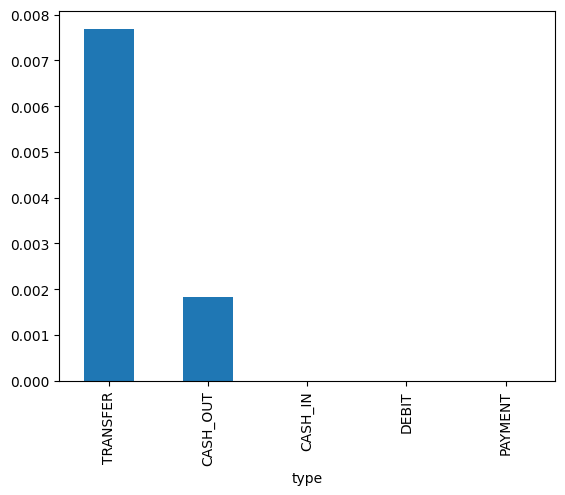

In [9]:
#Fraud Rate by transaction type
df.groupby('type')['isFraud'].mean().sort_values(ascending=False).plot(kind='bar')
plt.show()

In [10]:
#Time based overview

df['hour'] = df['step'] % 24

#Aggregate hourly statistics

hourly_stats = (
    df.groupby('hour')
    .agg(
        total_transactions=('isFraud','count'),
        fraud_transactions=('isFraud','sum'),
        fraud_rate=('isFraud','mean')
    ).reset_index()
)
display(hourly_stats.head())

,hour,total_transactions,fraud_transactions,fraud_rate
0,0,71587,300,0.004191
1,1,27111,358,0.013205
2,2,9018,372,0.041251
3,3,2007,326,0.162431
4,4,1241,274,0.220790


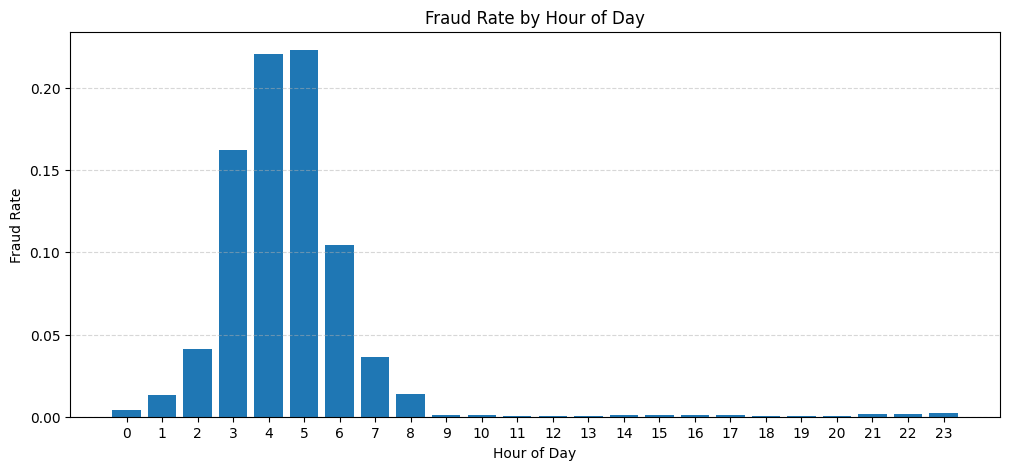

In [11]:
#Fraud rate by hour

plt.figure(figsize=(12,5))
plt.bar(hourly_stats['hour'], hourly_stats['fraud_rate'])
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Hour of Day')
plt.xticks(range(0,24))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

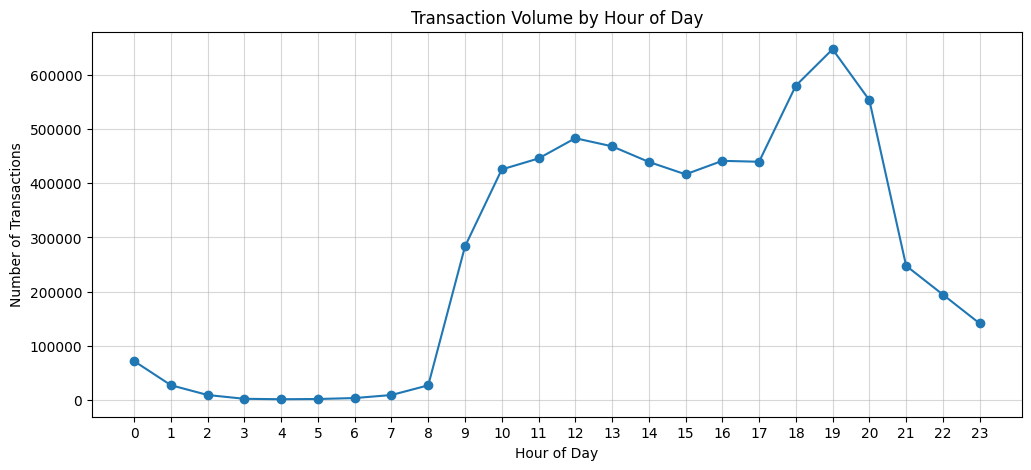

In [12]:
#Transaction volume by hour

plt.figure(figsize=(12,5))
plt.plot(hourly_stats['hour'], hourly_stats['total_transactions'], marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.title('Transaction Volume by Hour of Day')
plt.xticks(range(0,24))
plt.grid(alpha=0.5)
plt.show()

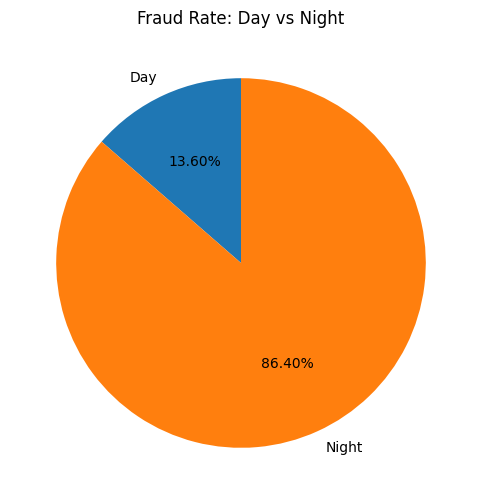

In [15]:
#Day vs Night Fraud Comparison
plt.figure(figsize=(6,6))

df['is_night'] = df['hour'].isin([0,1,2,3,4,5,22,23]).astype(int)

day_night_fraud = (
    df.groupby('is_night')['isFraud']
    .mean()
    .rename({0:'Day', 1:'Night'})
)

day_night_fraud.plot(
    kind='pie',
    autopct='%1.2f%%',
    startangle=90,
    legend=False
)

plt.ylabel('')
plt.title('Fraud Rate: Day vs Night')
plt.show()

Text(0.5, 1.0, 'Correlation heatmap of Transaction Features')

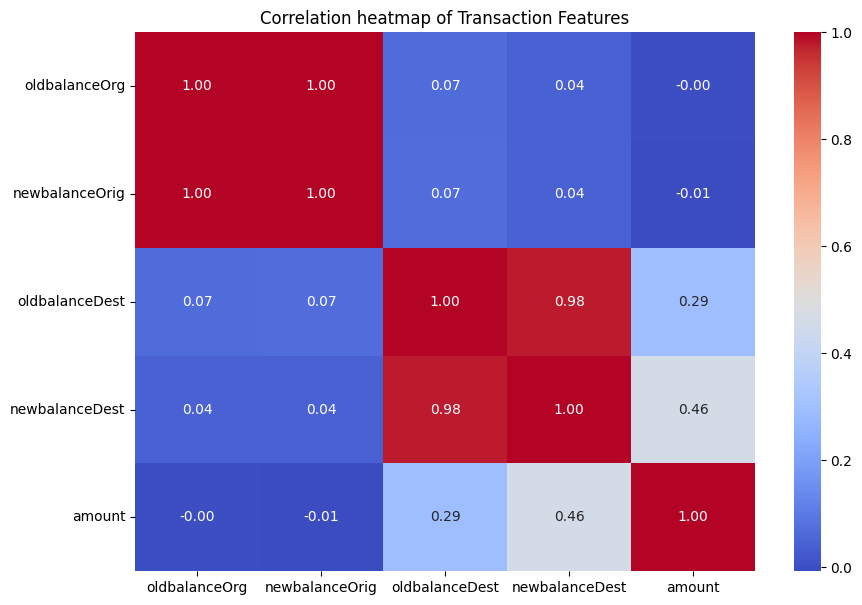

In [17]:
#Corelation Check
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,7))
corr = df[['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest','newbalanceDest', 'amount']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation heatmap of Transaction Features')

This correlation matrix reveals severe multicollinearity between pre- and post-transaction balances, indicating redundancy. To address this balance -difference features were engineered and redundant variables need to be removed, improving model stability and interpretability.

# Feature Engineering & Data Cleaning

In [18]:
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']

#Feature Reduction (for linear models, logistic regression)
df = df.drop(columns=[
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
])

In [21]:
# df.drop(columns=['amount_bin'],inplace=True)
# df.fillna(0, inplace=True)

le = LabelEncoder()
df['type_enc'] = le.fit_transform(df['type'])

df.drop(['nameOrig', 'nameDest', 'type'], axis=1, inplace=True)

# Train Test Split

In [23]:
X = df.drop(columns=['isFraud', 'isFlaggedFraud'])
y = df['isFraud'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = RobustScaler() # (x-median)/IQR
num_cols = X_train.select_dtypes(include=[np.number]).columns
scaler.fit(X_train[num_cols])

X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols] = scaler.transform((X_test[num_cols]))

# Model Training and Evaluation

In [24]:
models = {}

#Logistic Regression
print("Training Logistic Regression (fast mode)")
lr = LogisticRegression(
    max_iter=300,
    solver='lbfgs',
    class_weight='balanced',
    n_jobs=-1
)
lr.fit(X_train, y_train)
models['LogisticRegression'] = lr
print("Logistic Regression trained")

#Random Forest
print("Training Random Forest (optimized)")
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=12,
    min_samples_leaf=100,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
models['RandomForest'] = rf
print("Random Forest trained")

#XGBoost

if xgb is not None:
    print("Training XGBoost")
    scale_pos = (y_train==0).sum() / (y_train==1).sum()
    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        scale_pos_weight=scale_pos,
        tree_method='hist',
        n_jobs=-1
    )
    xgb_model.fit(X_train, y_train)
    models['XGBoost'] = xgb_model
    print("XGBoost trained")
else:
    print("XGBoost not installed")

Training Logistic Regression (fast mode)
Logistic Regression trained
Training Random Forest (optimized)
Random Forest trained
XGBoost not installed


In [27]:
results = []
for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        scores = model.predict_proba(X_test)[:,1]
    else:
        scores = model.decision_function(X_test)
    print("\n", name)
    print(classification_report(y_test, (scores>0.5).astype(int)))
    results.append({'model':name, 'roc_auc':roc_auc_score(y_test,scores), 'auprc':average_precision_score(y_test,scores)})
pd.DataFrame(results).sort_values('auprc', ascending=False)


 LogisticRegression
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270881
           1       0.03      0.89      0.05      1643

    accuracy                           0.96   1272524
   macro avg       0.51      0.93      0.52   1272524
weighted avg       1.00      0.96      0.98   1272524


 RandomForest
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270881
           1       0.07      0.96      0.12      1643

    accuracy                           0.98   1272524
   macro avg       0.53      0.97      0.56   1272524
weighted avg       1.00      0.98      0.99   1272524



,model,roc_auc,auprc
1,RandomForest,0.997632,0.841487
0,LogisticRegression,0.977524,0.550562


In [28]:
from sklearn.metrics import precision_recall_curve

model = models['RandomForest']
y_scores = model.predict_proba(X_test)[:,1]
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
candidates = [
    (t, p, r) for t, p, r in zip(thresholds, precision[:-1], recall[:-1])
    if r >= 0.90
]
best_threshold, best_p, best_r = max(candidates, key=lambda x: x[1])
print(f"Best threshold: {best_threshold:.4f}")
print(f"Precision {best_p:.3f}, Recall: {best_r:.3f}")

Best threshold: 0.7458
Precision 0.260, Recall: 0.900


After threshold optimization, the model flags transactions only when fraud probability exceeds 0.75.

# Fine Tuning the model

In [29]:
rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=200,        # huge impact on precision
    min_samples_split=500,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",500
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",200
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [30]:
lr_tuned = LogisticRegression(
    max_iter=300,
    solver='lbfgs',
    class_weight='balanced',
    C=0.3                     # stronger regularization
)

lr_tuned.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.3
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [31]:
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate(model, X, y):
    scores = model.predict_proba(X)[:,1]
    return {
        "ROC-AUC": roc_auc_score(y, scores),
        "PR-AUC": average_precision_score(y, scores)
    }
print("RF :", evaluate(rf_tuned, X_test, y_test))
print("LR :", evaluate(lr_tuned, X_test, y_test))

RF : {'ROC-AUC': 0.9977525113469302, 'PR-AUC': 0.8320049214362165}
LR : {'ROC-AUC': 0.9774936739612737, 'PR-AUC': 0.5504119584396516}


# Saving the fine tuned model

In [32]:
models = {
    "LogisticRegression": lr_tuned,
    "RandomForest": rf_tuned,
}

best_model_name = max(results, key=lambda x: x['auprc'])['model']
best_model = models[best_model_name]


best_model_artifact = {
    "model_name": best_model_name,
    "model": best_model,
    "threshold": best_threshold,
    "features": X_train.columns.tolist()
}

joblib.dump(best_model_artifact, "best_fraud_model_tuned.pkl")

print(f" Saved best model: {best_model_name}")
print(f" Decision threshold: {best_threshold:.4f}")

 Saved best model: RandomForest
 Decision threshold: 0.7458


# Testing

In [33]:
artifact = joblib.load("best_fraud_model_tuned.pkl")
model = artifact["model"]
threshold = artifact["threshold"]
features = artifact["features"]

# Predict on test data
y_scores = model.predict_proba(X_test[features])[:, 1]
y_pred = (y_scores >= threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Summary table
summary = pd.DataFrame({
    "Count": [tp, fn, fp, tn]
}, index=[
    "Correctly detected fraud (TP)",
    "Missed fraud (FN)",
    "False alarms (FP)",
    "Correct non-fraud (TN)"
])
print(summary)

# quick fraud recall check
print(f"\nFraud Recall: {tp / (tp + fn):.3f}")
print(f"Fraud Precision: {tp / (tp + fp):.3f}")

                                 Count
Correctly detected fraud (TP)     1511
Missed fraud (FN)                  132
False alarms (FP)                 6199
Correct non-fraud (TN)         1264682

Fraud Recall: 0.920
Fraud Precision: 0.196


By minimizing false alarms, it also lowers operational costs and improves customer trust, enabling safer transactions and supporting business growth.

While testing correctly allowed ~1.27 million legitimate transactions.

Precision: 20% Alerts: ~6,200 Missed fraud: only 132